# Heart Disease Prediction — Decision Tree Feature Importance Analysis

This notebook works with the [Heart Disease dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset) to build a `DecisionTreeClassifier` that predicts the presence of heart disease from a patient's clinical attributes.

**Goal.** While the notebook does walk through the full modeling pipeline (EDA, preprocessing, training, tuning, evaluation), the primary objective is not raw predictive accuracy — it is to extract and interpret **feature importance** from the trained tree, in order to identify which clinical measurements contribute most to the model's decisions.

**Workflow overview:**
1. Load and inspect the raw data
2. Explore feature distributions and relationships (EDA)
3. Preprocess the data and split it into train/test sets
4. Train a baseline Decision Tree
5. Tune hyperparameters with `GridSearchCV`
6. Evaluate the tuned model
7. Extract and visualize feature importance
8. Visualize the final decision tree structure

## 1. Import Libraries

Import the core libraries used throughout the notebook: `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for visualization, and the relevant `scikit-learn` modules for splitting the data, building the Decision Tree, tuning hyperparameters, and evaluating results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

## 2. Load Data & Initial Inspection

Load the dataset and perform a first pass of sanity checks before any analysis: preview the raw rows, confirm the dataset's shape, inspect column data types, review summary statistics for the numerical features, and check for missing values. This step establishes that the data is clean and ready for exploration.

In [2]:
org_df = pd.read_csv("heart.csv")
df = org_df.copy()
org_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
org_df.shape

(1025, 14)

In [4]:
org_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
org_df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
org_df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## 3. Exploratory Data Analysis (EDA)

Before modeling, explore the data visually to understand the target balance, the distribution of categorical and numerical features, and how features relate to one another. These observations provide context for interpreting the feature importance results later on.

### 3.1 Target Distribution

Check how balanced the target classes are (presence vs. absence of heart disease). A roughly balanced target means accuracy is a reasonable evaluation metric and that no special class-imbalance handling is strictly required.

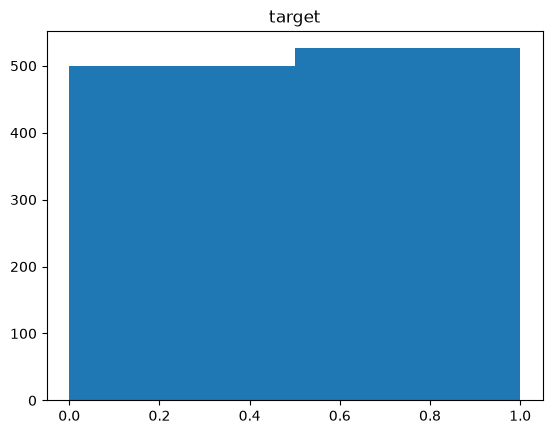

In [7]:
plt.hist(org_df["target"], bins=2)
plt.title("target")
plt.show()

### 3.2 Categorical Feature Distributions

Visualize the frequency of each category within the categorical clinical attributes (e.g., chest pain type, fasting blood sugar, thalassemia). This helps identify dominant categories and rare ones that may carry less statistical weight during training.

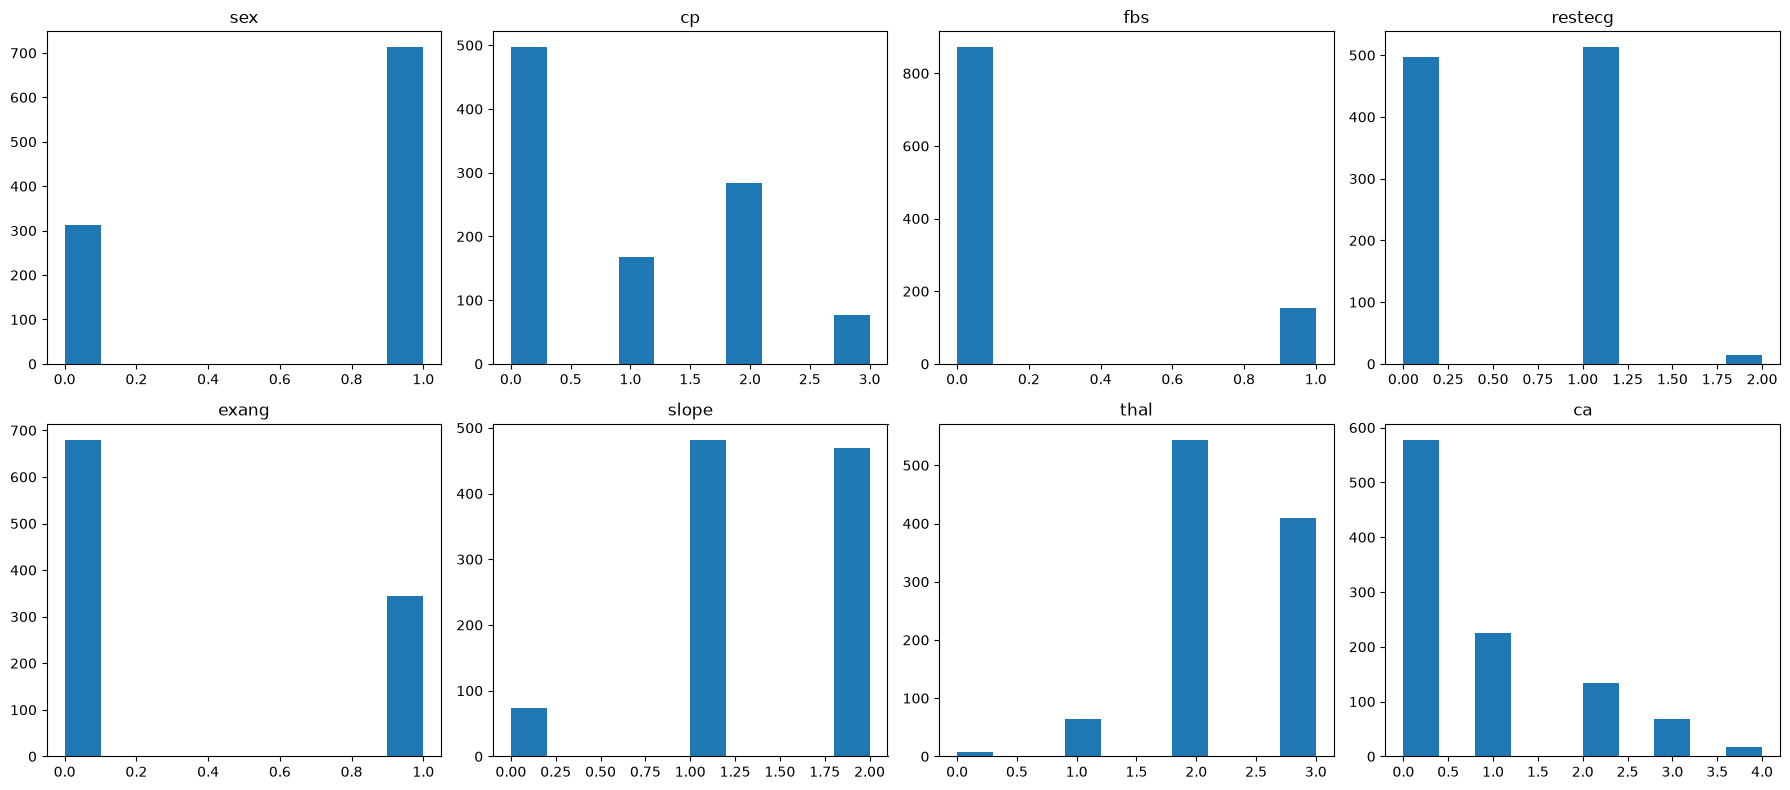

In [8]:
categorical_columns = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal", "ca"]
plt.figure(figsize=(18, 8))

for i, column in enumerate(categorical_columns):
    plt.subplot(2, 4, i + 1)
    plt.hist(org_df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

### 3.3 Numerical Feature Distributions

Inspect the spread of the numerical attributes (age, resting blood pressure, cholesterol, max heart rate, ST depression) to get a sense of their range and to spot any obvious outliers before they are fed into the model.

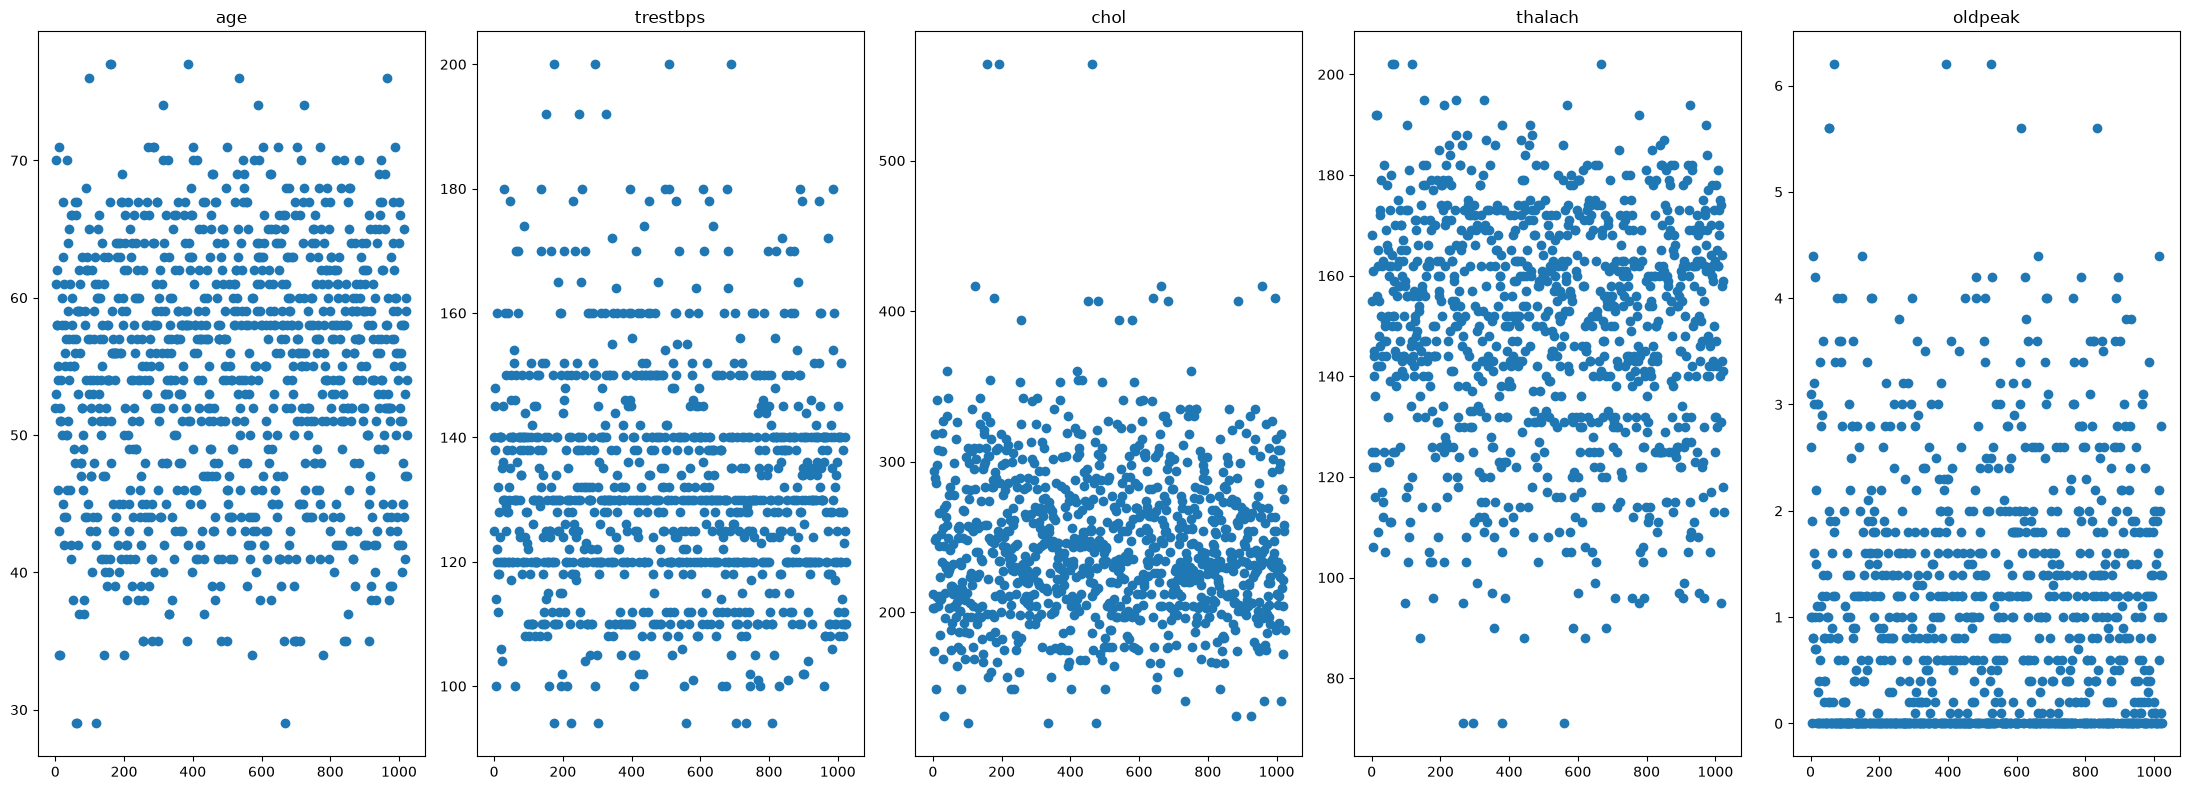

In [9]:
numerical_columns = [ "age", "trestbps", "chol", "thalach", "oldpeak"]
plt.figure(figsize=(22,8))
for i, column in enumerate(numerical_columns):
    plt.subplot(1,5,i+1)
    plt.scatter(org_df.index, org_df[column])
    plt.title(column)
    
plt.tight_layout()
plt.show()

### 3.4 Feature Correlation

Plot a correlation heatmap across all features to surface linear relationships between clinical attributes. This is a useful reference point to compare against the tree-based feature importance results obtained later — a feature can be important to the tree without being linearly correlated with the target, and vice versa.

<Axes: >

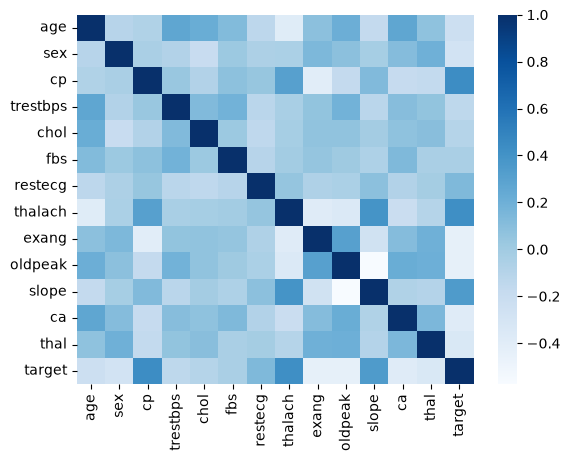

In [10]:
sns.heatmap(org_df.corr(), cmap="Blues")

## 4. Data Preprocessing

Prepare the data for modeling: confirm column types, cast columns to memory-efficient dtypes, separate the features (`X`) from the target (`y`), and split the data into training and test sets. The split uses `stratify=y` to preserve the target's class balance in both sets, and a fixed `random_state` for reproducibility. Note that feature scaling is not required here, since Decision Trees split on threshold values per feature independently and are not sensitive to feature magnitude.

In [11]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [12]:
uint8_columns = ["age", "sex", "cp", "trestbps", "fbs", "restecg", "thalach", "exang", "slope", "thal", "ca", "target"]
for column in uint8_columns:
    df[column] = df[column].astype("uint8")
df["chol"] = df["chol"].astype("uint16")
df["oldpeak"] = df["oldpeak"].astype("float32")

In [13]:
X = df.drop("target", axis=1)
y = df["target"]

In [14]:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, shuffle=True, random_state=42)

## 5. Baseline Decision Tree

Train an initial, minimally-tuned `DecisionTreeClassifier` (with only `max_depth` constrained) to establish a performance baseline. This baseline is a reference point for measuring how much the later hyperparameter tuning actually improves the model. Visualizing the tree also gives an early, intuitive look at which features the model splits on first — the features closest to the root tend to carry the most importance.

In [15]:
clf = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
clf.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

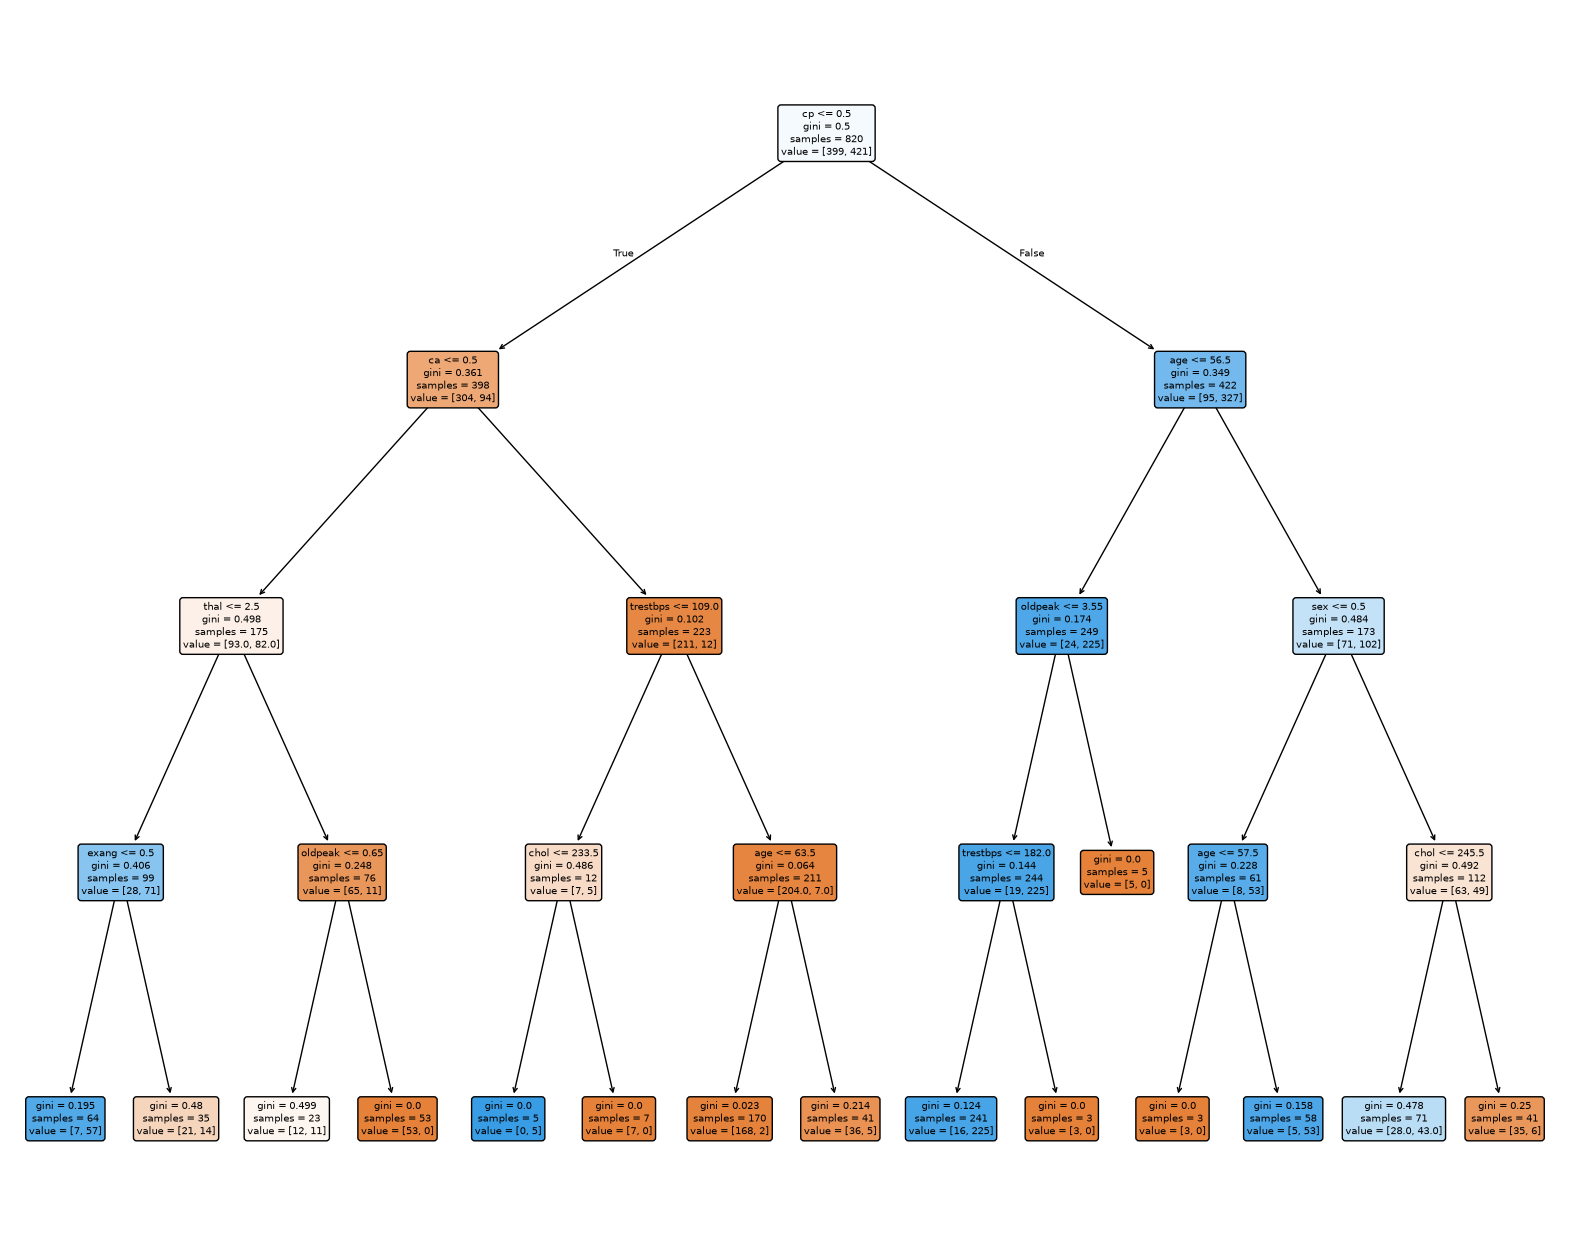

In [16]:
plt.figure(figsize=(20,16))
plot_tree(
    clf,
    feature_names=X.columns.values,
    filled=True,
    rounded=True
)
plt.show()


In [17]:
y_test_pred = clf.predict(x_test)
y_train_pred = clf.predict(x_train)

In [18]:
print(f"y_train : \n{classification_report(y_train, y_train_pred)}")
print(65*"-")
print(f"y_test : \n{classification_report(y_test, y_test_pred)}")

y_train : 
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       399
           1       0.87      0.91      0.89       421

    accuracy                           0.89       820
   macro avg       0.89      0.88      0.89       820
weighted avg       0.89      0.89      0.89       820

-----------------------------------------------------------------
y_test : 
              precision    recall  f1-score   support

           0       0.86      0.80      0.83       100
           1       0.82      0.88      0.85       105

    accuracy                           0.84       205
   macro avg       0.84      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205



## 6. Hyperparameter Tuning

Search over a grid of Decision Tree hyperparameters — split criterion, depth, leaf/split sample thresholds, feature sampling, and minimum impurity decrease — using `GridSearchCV` with 5-fold cross-validation to find the combination that generalizes best on unseen folds of the training data. `class_weight="balanced"` is used to make sure both classes contribute equally to the split criteria.

In [26]:
pipeline = Pipeline(
    steps=[
        ("model", DecisionTreeClassifier(random_state=10))
    ]
)
params_grid = {
    "model__criterion": ["entropy", "gini", "log_loss"],
    "model__max_depth": [5, 6, 7, 8],
    "model__min_samples_leaf": [3, 4, 5, 6],
    "model__min_samples_split": [8, 9, 10, 11],
    "model__max_features": ["log2", "sqrt"], 
    "model__min_impurity_decrease": [0.05, 0.01, 0.005],
    "model__class_weight": ["balanced"]
}
grid_search = GridSearchCV(pipeline, param_grid=params_grid, scoring="accuracy", n_jobs=-1, verbose=2)

In [27]:
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 1152 candidates, totalling 5760 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=10))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': ['balanced'], 'model__criterion': ['entropy', 'gini', ...], 'model__max_depth': [5, 6, ...], 'model__max_features': ['log2', 'sqrt'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator i

In [28]:
print(f"best params :\n{grid_search.best_params_}")

best params :
{'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 7, 'model__max_features': 'log2', 'model__min_impurity_decrease': 0.005, 'model__min_samples_leaf': 3, 'model__min_samples_split': 9}


## 7. Best Model Evaluation

Extract the best-performing estimator found by the grid search and evaluate it on both the training and test sets. Comparing the two classification reports shows whether the tuned model generalizes well or is still overfitting the training data, and whether tuning improved on the baseline from Section 5.

In [29]:
best_model = grid_search.best_estimator_.named_steps["model"] 
y_best_test_pred = best_model.predict(x_test)
y_best_train_pred = best_model.predict(x_train)

In [30]:
print(f"y_train : \n{classification_report(y_train, y_best_train_pred)}")
print(65*"-")
print(f"y_test : \n{classification_report(y_test, y_best_test_pred)}")

y_train : 
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       399
           1       0.91      0.91      0.91       421

    accuracy                           0.91       820
   macro avg       0.91      0.91      0.91       820
weighted avg       0.91      0.91      0.91       820

-----------------------------------------------------------------
y_test : 
              precision    recall  f1-score   support

           0       0.84      0.81      0.83       100
           1       0.83      0.86      0.84       105

    accuracy                           0.83       205
   macro avg       0.83      0.83      0.83       205
weighted avg       0.83      0.83      0.83       205



## 8. Extracting Feature Importance

This is the core objective of the notebook. `feature_importances_` reports, for each input feature, its normalized total contribution to reducing impurity (based on the tuned model's `criterion`) across every split in the tree where that feature was used. Features that are used higher up in the tree, and/or that produce cleaner splits, receive a higher score. All scores sum to 1.

Text(0.5, 1.0, 'features Importance')

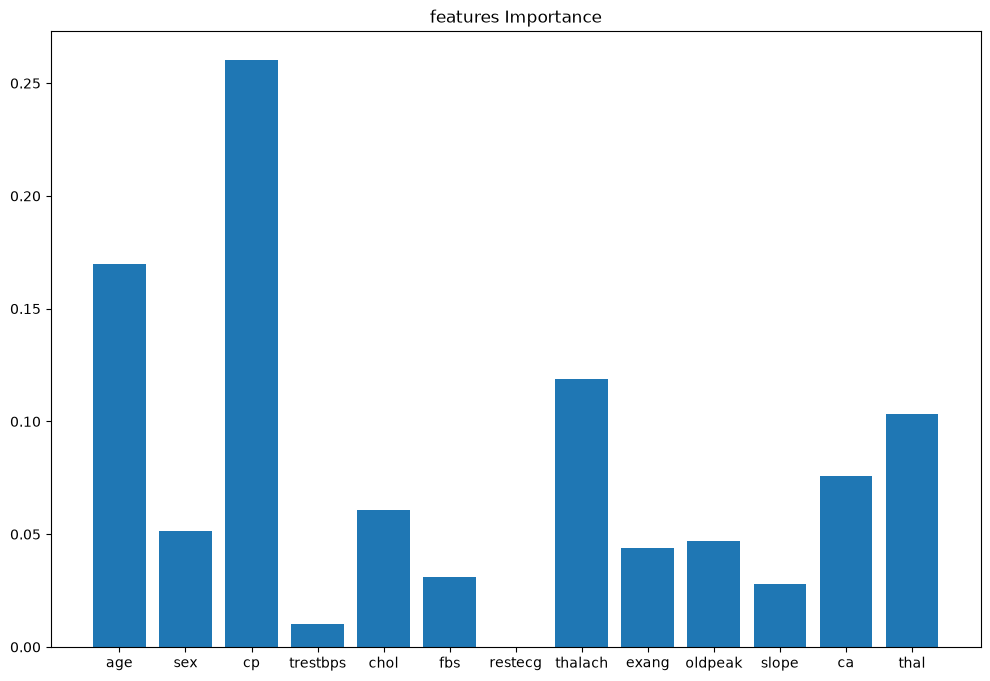

In [33]:
features_importance = best_model.feature_importances_
plt.figure(figsize=(12,8))
plt.bar(X.columns.values, features_importance)
plt.title("features Importance")

### Interpretation

Based on the chart above, three features stand out well above the rest: **`cp`** (chest pain type, ~0.26), **`age`** (~0.17), and **`thalach`** (maximum heart rate achieved, ~0.12), followed closely by **`thal`** (thalassemia result, ~0.10) and **`ca`** (number of major vessels colored by fluoroscopy, ~0.08). This is consistent with clinical intuition: chest pain type is often the most direct symptomatic indicator used in cardiac diagnosis, while age, exercise-induced heart rate response, and vessel/thalassemia results are well-established cardiovascular risk indicators.

At the other end, **`restecg`** (resting electrocardiographic results) contributes essentially nothing to the model, and **`trestbps`** (resting blood pressure) contributes very little (~0.01). This suggests that, in this particular dataset, these two features either carry little independent predictive signal or their information is already captured by other, more dominant features (e.g., `age` or `thalach`) once the tree has split on them.

It's worth noting that Decision Tree feature importance can be somewhat unstable — small changes in the data or in `random_state` can shift which correlated feature "wins" a split. Cross-checking this ranking against an ensemble method (e.g., Random Forest) or a model-agnostic method (e.g., permutation importance) would be a natural next step to confirm how robust this ranking is.

## 9. Decision Tree Visualization

Plot the full structure of the tuned decision tree. This makes the feature importance results concrete: the root and near-root nodes should correspond to the highest-ranked features from Section 8, and each path from root to leaf shows the exact sequence of decisions the model uses to arrive at a diagnosis.

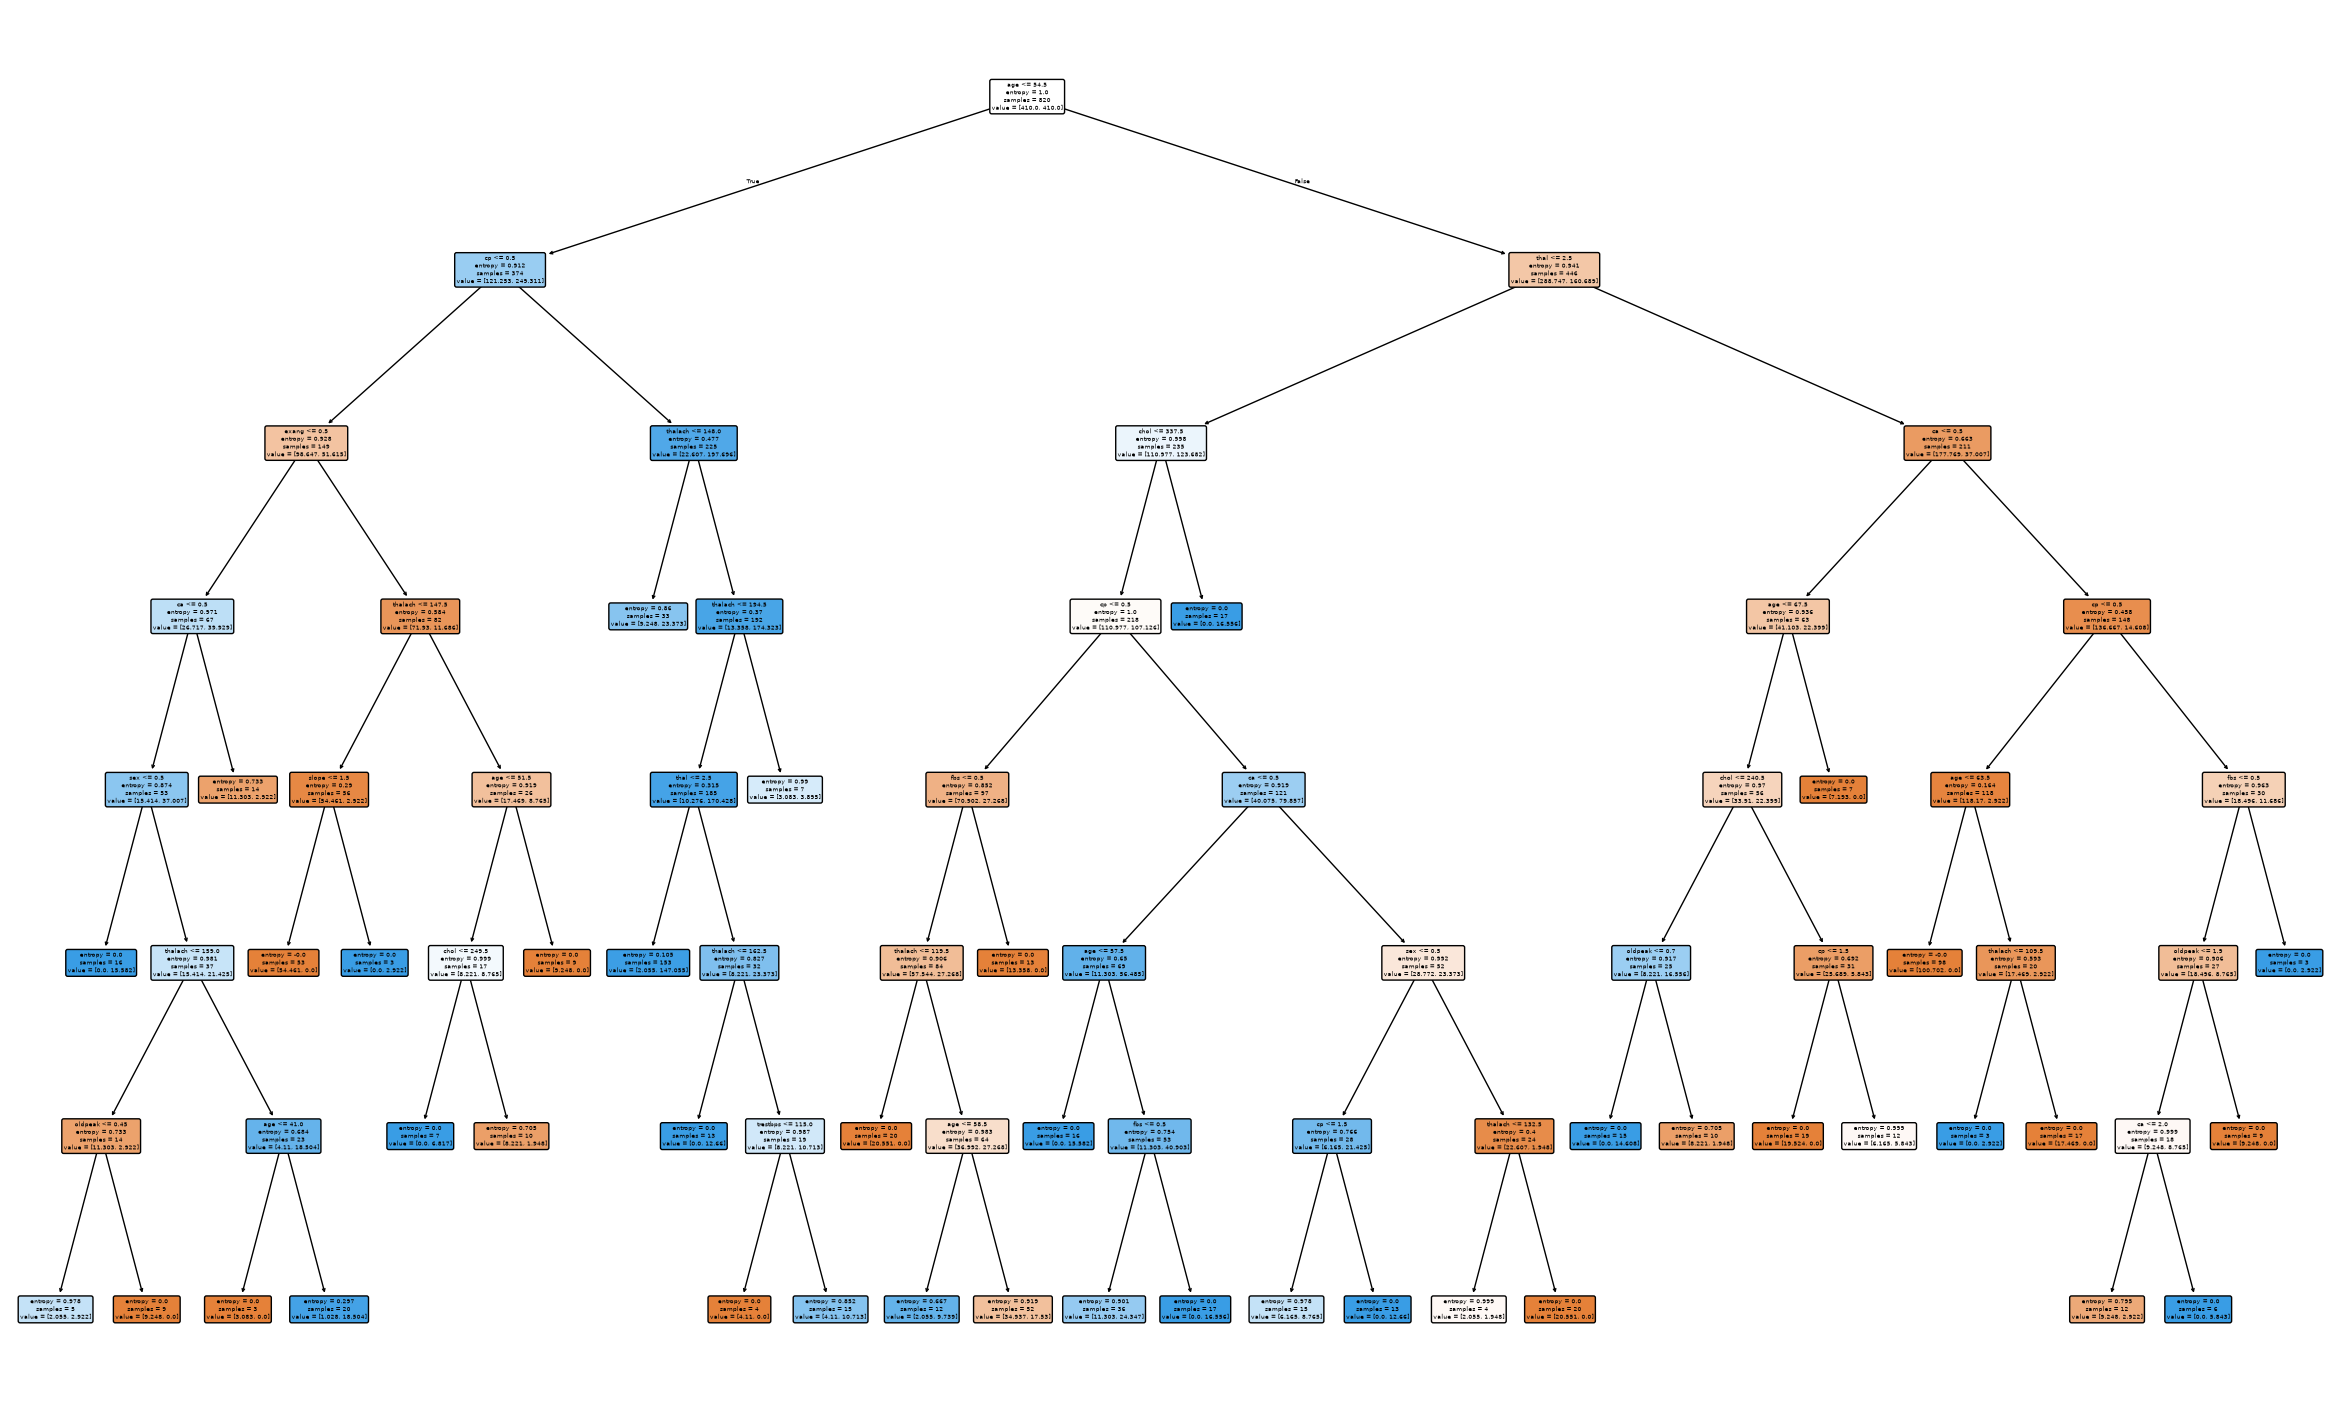

In [32]:
plt.figure(figsize=(30,18))
plot_tree(
    best_model,
    feature_names=X.columns.values,
    filled=True,
    rounded=True
)
plt.show()

## 10. Conclusion

**Summary.** A Decision Tree classifier was trained to predict the presence of heart disease and, after hyperparameter tuning via `GridSearchCV`, reached a test accuracy of about 83% (F1-score ~0.83–0.84 for both classes), compared to a training accuracy of ~91% — indicating the model generalizes reasonably well without severe overfitting. The feature importance analysis identified **chest pain type (`cp`)**, **age**, and **maximum heart rate achieved (`thalach`)** as the strongest predictors, with **thalassemia (`thal`)** and **number of major vessels (`ca`)** also contributing meaningfully, while `restecg` and `trestbps` were largely uninformative for this model.
